In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [4]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


In [7]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB


In [9]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [10]:
ratings["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [11]:
n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_movies_total = movies["movieId"].nunique()

print("Unique users:", n_users)
print("Movies with ratings:", n_movies_rated)
print("Total movies:", n_movies_total)

Unique users: 610
Movies with ratings: 9724
Total movies: 9742


In [12]:
#Data Quality Check
print("Missing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [13]:
print("Duplicate rows in movies:",
      movies.duplicated().sum())

print("Duplicate rows in ratings:",
      ratings.duplicated().sum())

Duplicate rows in movies: 0
Duplicate rows in ratings: 0


In [14]:
duplicate_user_movie = ratings.duplicated(
    subset=["userId", "movieId"]
).sum()

print("Duplicate user-movie ratings:",
      duplicate_user_movie)

Duplicate user-movie ratings: 0


In [15]:
ratings["rating"].value_counts().sort_index()

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

In [16]:
#Data Preparation
#Merge movies and ratings
df = ratings.merge(
    movies,
    on="movieId",
    how="left"
)

df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [17]:
df["year"] = df["title"].str.extract(r"\((\d{4})\)")
df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)
df[["title", "year"]].head()

,title,year
0,Toy Story (1995),1995.0
1,Grumpier Old Men (1995),1995.0
2,Heat (1995),1995.0
3,Seven (a.k.a. Se7en) (1995),1995.0
4,"Usual Suspects, The (1995)",1995.0


In [18]:
genre_df = df.assign(
    genre=df["genres"].str.split("|")
).explode("genre")

In [ ]:
#tach genres
genre_df[
    ["movieId", "title", "rating", "genre"]
].head(10)

,movieId,title,rating,genre
0,1,Toy Story (1995),4.0,Adventure
0,1,Toy Story (1995),4.0,Animation
0,1,Toy Story (1995),4.0,Children
0,1,Toy Story (1995),4.0,Comedy
0,1,Toy Story (1995),4.0,Fantasy
1,3,Grumpier Old Men (1995),4.0,Comedy
1,3,Grumpier Old Men (1995),4.0,Romance
2,6,Heat (1995),4.0,Action
2,6,Heat (1995),4.0,Crime
2,6,Heat (1995),4.0,Thriller


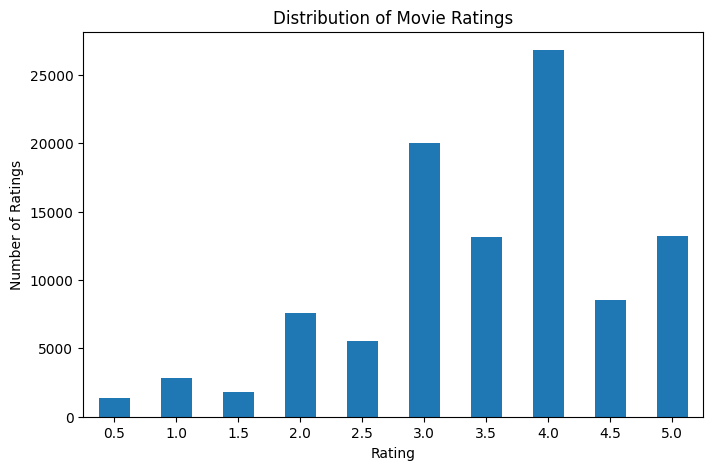

In [ ]:
#EDA 1 — Rating Distribution
rating_counts = (
    ratings["rating"]
    .value_counts()
    .sort_index()
)

rating_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()
#Ratings are concentrated around the middle-to-high range, while very low ratings occur less frequently.

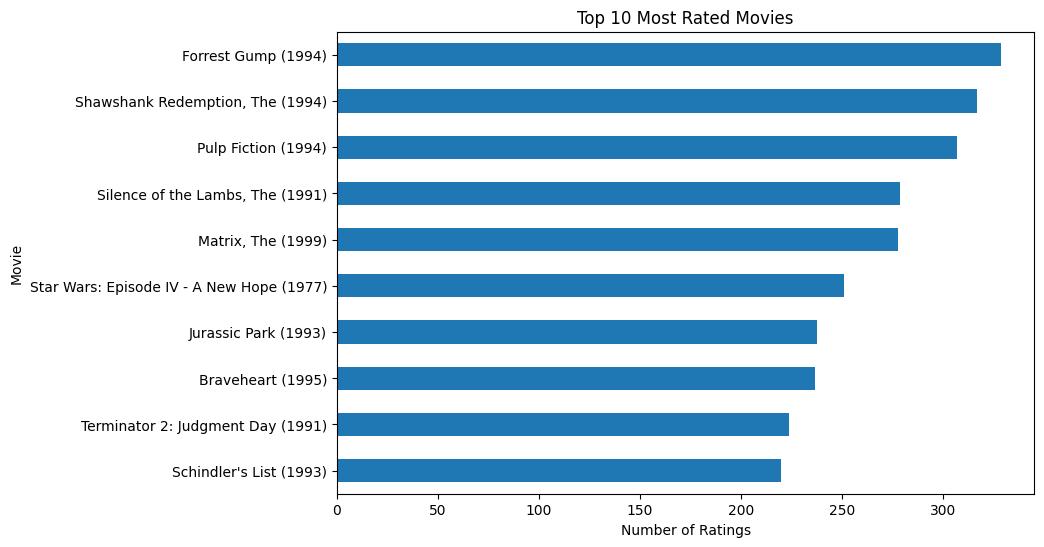

In [ ]:
#EDA — Top 10 Most Rated Movies
movie_rating_counts = (
    df.groupby("title")
    ["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

movie_rating_counts.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.show()


In [ ]:
movie_stats = (
    df.groupby("title")
    .agg(
        avg_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

popular_movies = movie_stats[
    movie_stats["rating_count"] >= 50
]

top_rated = (
    popular_movies
    .sort_values(
        "avg_rating",
        ascending=False
    )
    .head(10)
)

top_rated
#Rating count should be 
#considered together with average rating when evaluating movie popularity or preference.

,title,avg_rating,rating_count
7593,"Shawshank Redemption, The (1994)",4.429022,317
3499,"Godfather, The (1972)",4.289062,192
3011,Fight Club (1999),4.272936,218
1961,Cool Hand Luke (1967),4.271930,57
2531,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
6999,Rear Window (1954),4.261905,84
3500,"Godfather: Part II, The (1974)",4.259690,129
2334,"Departed, The (2006)",4.252336,107
3564,Goodfellas (1990),4.250000,126
1593,Casablanca (1942),4.240000,100


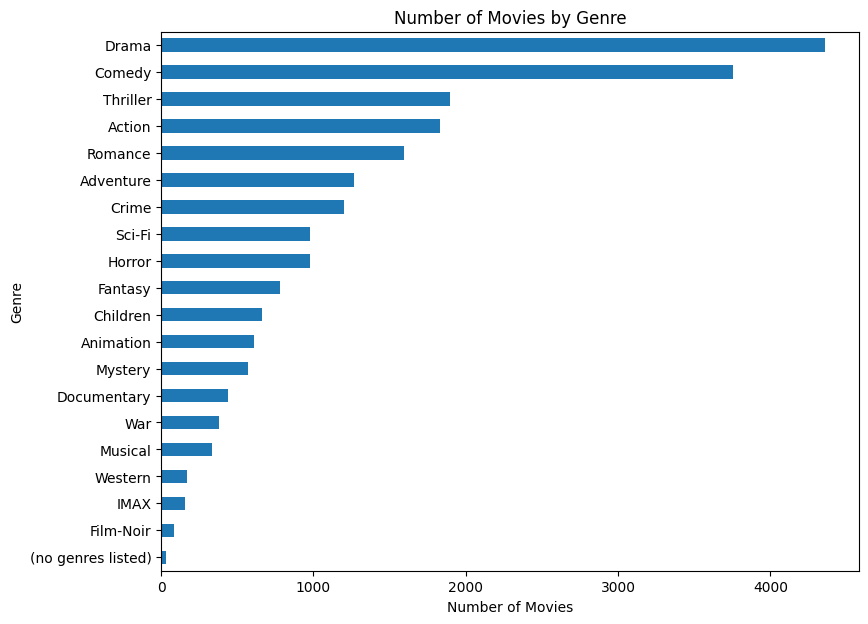

In [24]:
movie_genres = movies.assign(
    genre=movies["genres"].str.split("|")
).explode("genre")
genre_movie_counts = (
    movie_genres.groupby("genre")
    ["movieId"]
    .nunique()
    .sort_values(ascending=False)
)
genre_movie_counts.sort_values().plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Number of Movies by Genre")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

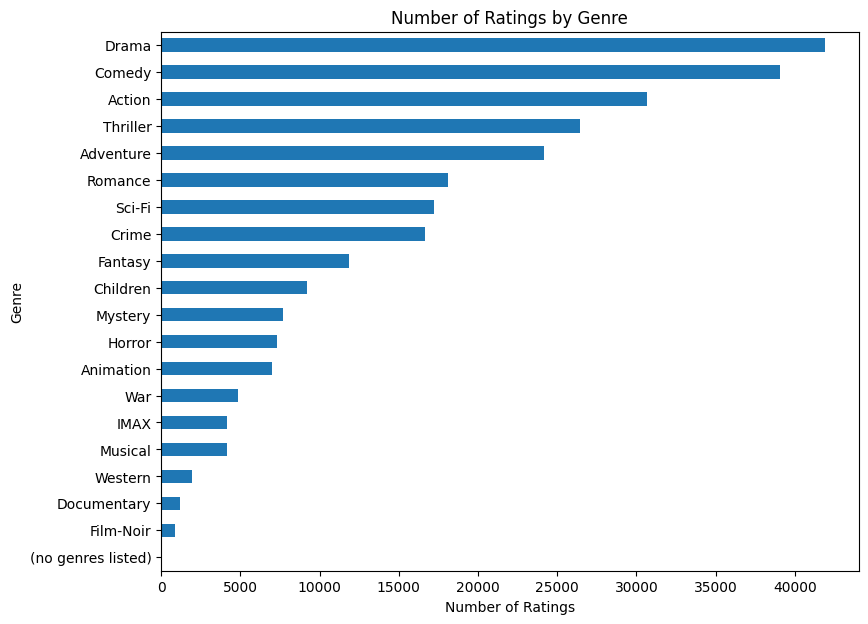

In [23]:
#EDA — Number of Ratings by Genre
genre_rating_counts = (
    genre_df.groupby("genre")
    ["rating"]
    .count()
    .sort_values(ascending=False)
)
genre_rating_counts.sort_values().plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Number of Ratings by Genre")
plt.xlabel("Number of Ratings")
plt.ylabel("Genre")
plt.show()

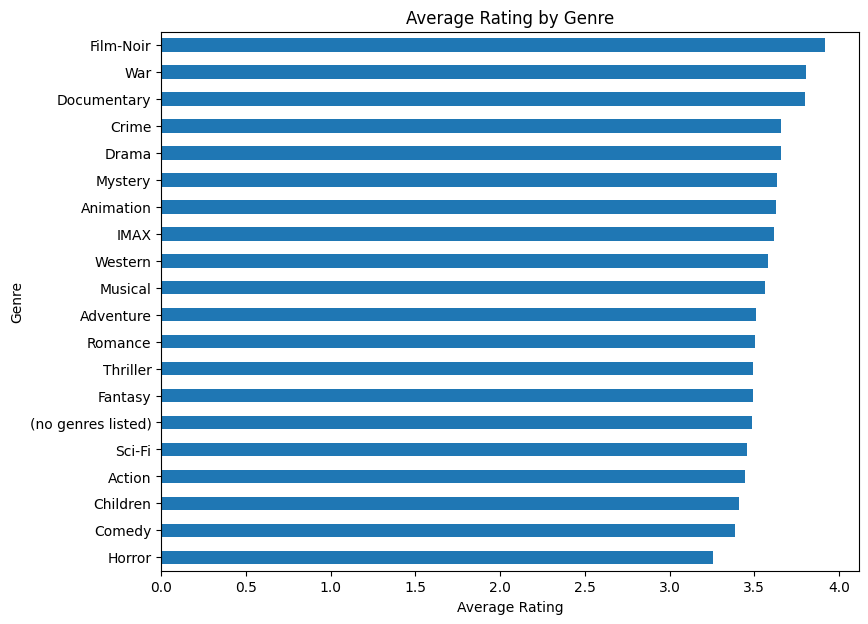

In [25]:
genre_avg_rating = (
    genre_df.groupby("genre")
    ["rating"]
    .mean()
    .sort_values(ascending=False)
)
genre_avg_rating.sort_values().plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

In [26]:
user_activity = (
    ratings.groupby("userId")
    .size()
)

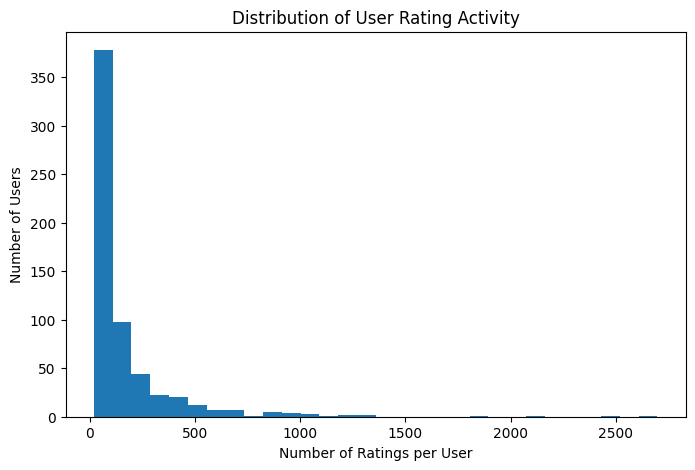

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    user_activity,
    bins=30
)

plt.title("Distribution of User Rating Activity")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.show()
#User activity is unevenly distributed, meaning some users contribute much more information than others.

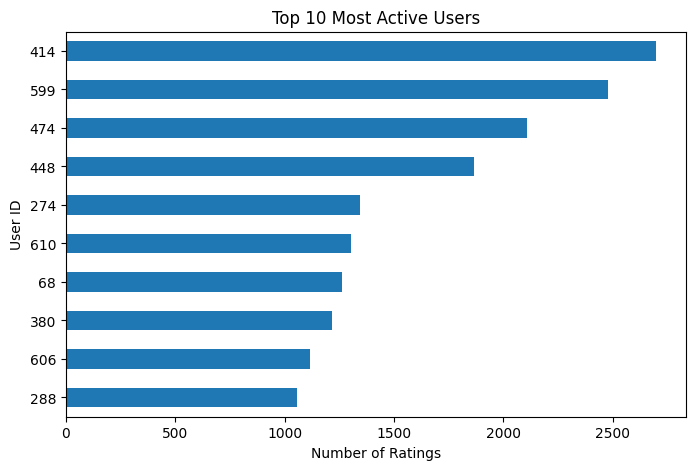

In [28]:
top_users = (
    user_activity
    .sort_values(ascending=False)
    .head(10)
)
top_users.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Most Active Users")
plt.xlabel("Number of Ratings")
plt.ylabel("User ID")
plt.show()

In [30]:
movies_year = movies.copy()

movies_year["year"] = (
    movies_year["title"]
    .str.extract(r"\((\d{4})\)")
)

movies_year["year"] = pd.to_numeric(
    movies_year["year"],
    errors="coerce"
)

In [31]:
movies_per_year = (
    movies_year.groupby("year")
    ["movieId"]
    .count()
)

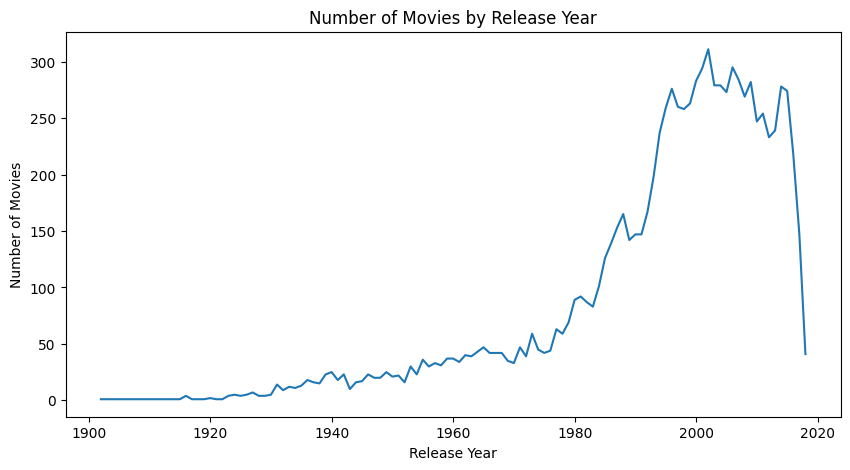

In [ ]:
movies_per_year.plot(
    figsize=(10, 5)
)

plt.title("Number of Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()
#how the dataset covers different periods of movie history.

In [29]:
summary = {
    "Number of Users": ratings["userId"].nunique(),
    "Number of Movies": movies["movieId"].nunique(),
    "Number of Ratings": len(ratings),
    "Average Rating": ratings["rating"].mean()
}

summary

{'Number of Users': 610,
 'Number of Movies': 9742,
 'Number of Ratings': 100836,
 'Average Rating': 3.501556983616962}